# Algunos atajos

* b: una vez fuera de la celda, te permite agregar una celda de código nueva.
* dd: una vez afuera, elimina la celda correspondiente.
* m: convierte la celda seleccionada a una celda de texto (markdown).
* ctrl + enter: ejecutar la celda.

---

# Clase 5: Desarrollo de aplicación para un gimnasio

1. **Diseñar e implementar un sistema de login**: Flujo asociado al sistema de login.

a. Crear la ventana base para el sistema de login.

In [12]:
# tkinter sirve para diseñar interfaces de usuario con Python
import tkinter as tk

# Instanciar/inicializacion nuestra ventana
login = tk.Tk()

# configurar un tamaño
#             largo x Ancho
login.geometry('400x200')

# configurar un titulo
login.title('Login 🥸')

# Ejecutamos en bucle la interfaz
login.mainloop()

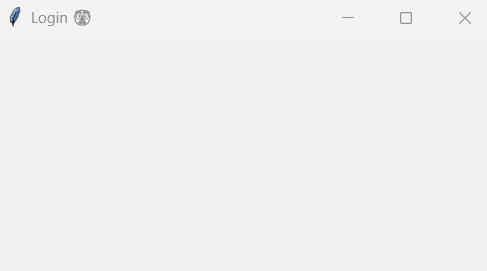

b. Crear la base de datos y la tabla con la información de los admins.

nombre|passwords
---|---
Luis|1234

In [14]:
# importamos la libreria sql para trabajar
import sqlite3 as sql

# Definir el query para crear la tabla
query_create = """
CREATE TABLE
    Administradores(
        nombre TEXT,
        passwords TEXT
    )
"""

query_insert = """
INSERT INTO 
    Administradores
VALUES(
    'Luis',
    '1234'
    )
"""

# Crear la base de datos y nos conectamos a ella
con = sql.connect("Gym_pym.db")

# Definimos el cursor (puente)
cur = con.cursor()

# Ejecutamos la sentencia SQL
cur.execute(query_create)
cur.execute(query_insert)

# Guardamos cambios con un commit
con.commit()

# Cerramos la conexion
con.close()

In [16]:
# Codigo para realizar la consulta a la tabla Administradores
import pandas as pd

# conectamos a la base de datos
con = sql.connect("Gym_pym.db")

# hacemos la conuslta mediante pandas
df = pd.read_sql_query("SELECT * FROM Administradores", con)

# cerramos la conexion
con.close()

# mandamos a llamar a nuestro dataframe
df

,nombre,passwords
0,Luis,1234


c. Crear la caja de texto para el password y un botón para ingresar

In [67]:
# herramientos de tkinter
from tkinter import ttk

# Instanciar/inicializacion nuestra ventana
login = tk.Tk()

# configurar un tamaño
#             largo x Ancho
login.geometry('400x200')

# configurar un titulo
login.title('Login 🥸')

##########################################################################
##########################################################################

# seccion de espacios en blanco para un espacio de identacion
etiqueta_espacio_blanco_1 = ttk.Label(login, text='                      ')
etiqueta_espacio_blanco_1.grid(row=1, column=0)

# Saltos de linea
etiqueta_espacio_blanco_2 = ttk.Label(login, text='                      ')
etiqueta_espacio_blanco_2.grid(row=2, column=1)

etiqueta_espacio_blanco_3 = ttk.Label(login, text='                      ')
etiqueta_espacio_blanco_3.grid(row=3, column=1)

# agregar un texto ttk.Label(ventana, texto)
etiqueta_titulo_login = ttk.Label(login, 
                                  text='Mi primera aplicación web',
                                  font=('Arial', 16))

# localizacion de nuestra etiqueta
etiqueta_titulo_login.grid(row=1, column=1, sticky='NSWE')

etiqueta_password = ttk.Label(login, text='Password', font=('Arial', 12))
etiqueta_password.grid(row=4, column=0, sticky='NSWE')

##########################################################################
##########################################################################
# Procedemos a colocar una caja de texto
caja_etiqueta_password = ttk.Entry(login, show='*')
# padx: margen horizontal (para no tener todo pegado)
caja_etiqueta_password.grid(row=4, column=1, sticky='NSWE', padx='10')

# Ejecutamos en bucle la interfaz
login.mainloop()

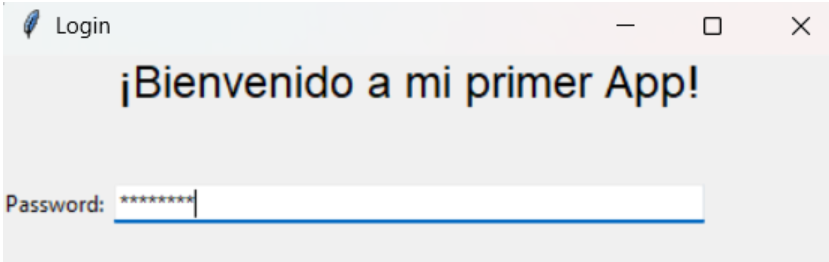

## Resumen parcial de códigos

* ``ventana = tk.Tk()``: creas tu ventana
* ``ventana.geometry()``: configuración del tamaño de la ventana
* ``ventana.title()``: configurar un título a la ventana
* ``ttk``: es parte de la librería de tkinter que nos permite colocar herramientas dentro de nuestra ventana.
* ``ttk.Label()``: colocar etiquetas en nuestra venta --> ``.grid(x, y)``: nos permite colocar en el lugar coordenada la ubicación de la etiqueta de texto.
* ``ttk.Entry()``: nos permite colocar cajas de texto.
* ``ventana.mainloop()``: ejecuta en bucle nuestra aplicación o interfaz.

d. Implementar botones y montar "back-end" (lógica de programación) dentrás de nuestro sistema de login.

In [88]:
# mensajes emergente:
# error
# askyesorno
# info
from tkinter import messagebox

# Instanciar/inicializacion nuestra ventana
login = tk.Tk()

# configurar un tamaño
#             largo x Ancho
login.geometry('400x200')

# configurar un titulo
login.title('Login 🥸')

# seccion de espacios en blanco para un espacio de identacion
etiqueta_espacio_blanco_1 = ttk.Label(login, text='                      ')
etiqueta_espacio_blanco_1.grid(row=1, column=0)

# Saltos de linea
etiqueta_espacio_blanco_2 = ttk.Label(login, text='                      ')
etiqueta_espacio_blanco_2.grid(row=2, column=1)

etiqueta_espacio_blanco_3 = ttk.Label(login, text='                      ')
etiqueta_espacio_blanco_3.grid(row=3, column=1)

# agregar un texto ttk.Label(ventana, texto)
etiqueta_titulo_login = ttk.Label(login, 
                                  text='Mi primera aplicación web',
                                  font=('Arial', 16))

# localizacion de nuestra etiqueta
etiqueta_titulo_login.grid(row=1, column=1, sticky='NSWE')

etiqueta_password = ttk.Label(login, text='Password', font=('Arial', 12))
etiqueta_password.grid(row=4, column=0, sticky='NSWE')

# Procedemos a colocar una caja de texto
caja_etiqueta_password = ttk.Entry(login, show='*')
# padx: margen horizontal (para no tener todo pegado)
caja_etiqueta_password.grid(row=4, column=1, sticky='WE', padx='10')


##########################################################################
##########################################################################
# los botones van asociados con comandos: funcion
# Definicion de un boton: ttk.Button(ventana, texto, comando)
def ingresar():
    """ Comando asociado a boton_entrar_login.
    * Nos conectaremos a la bbdd para traernos los passwords
    registrados.
    """
    # Parte 1: traernos la lista con los passwords
    con = sql.connect("Gym_pym.db")
    df = pd.read_sql_query("SELECT * FROM Administradores", con)
    con.close()
    passwords_lista = list(df['passwords'])
    # Parte 2: traernos ese password de la caja caja_etiqueta_password
    # dada una caja de texto, puedes extraer la informacion de ahi
    # con el metodo get()
    password_user = caja_etiqueta_password.get()
    # Parte 3: validar que el password sea correcto
    if password_user in passwords_lista:
        # en caso de que el password este en la lista permita
        # daremos acceso
        # ------------------booleano--------------------
        # yes ---> True
        # no  ---> False
        acceso = messagebox.askyesno(message='¿Deseas continuar?')

        if acceso:
            # si el administrador le da que si, entonces abriremos la 
            # app del gym (continuacion)
            login.destroy()
        else:
            # si le da en No el admin, entonces cerraremos la aplicacion
            login.destroy()
    else:
        # caso contrario, no daremos acceso
        messagebox.showerror('Contraseña incorrecta, intente de nuevo')
        
    
boton_entrar_login = ttk.Button(login, text='Ingresar', command=ingresar)
boton_entrar_login.grid(row=5, column=1)

boton_entrar_limpiar = ttk.Button(login, text='Limpiar', 
                                  command=lambda: caja_etiqueta_password.delete(0, tk.END))
boton_entrar_limpiar.grid(row=6, column=1)

# Ejecutamos en bucle la interfaz
login.mainloop()